In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, BayesianRidge, HuberRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn import metrics as sk_m
from scipy.stats import uniform
import optuna
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
import metrics_lib as ml
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')


# 1. Загрузка и подготовка данных

Загружаем предобработанный датасет, выделяем целевую переменную price_usd, разбиваем на train и test в соотношении 80 на 20.

In [33]:
data = pd.read_csv('cars_cleaned.csv')
data

,manufacturer_name,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,drivetrain,price_usd,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,1,1,190000,2010,0,2.5,0,1,2,10900.00,...,0,0,1,0,0,0,0,1,0,0
1,1,1,290000,2002,0,3.0,0,1,2,5000.00,...,0,0,1,0,0,0,0,1,0,0
2,1,1,402000,2001,0,2.5,0,1,2,2800.00,...,0,1,0,0,0,0,0,1,0,0
3,1,0,10000,1999,0,3.0,0,1,2,9999.00,...,1,0,0,0,0,0,0,1,0,0
4,1,1,280000,2001,0,2.5,0,1,2,2134.11,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38486,2,1,290000,2000,0,3.5,0,1,0,2750.00,...,1,0,0,0,0,0,0,1,0,0
38487,2,0,321000,2004,0,2.2,0,1,0,4800.00,...,0,0,0,0,1,0,0,0,0,0
38488,2,1,777957,2000,0,3.5,0,1,0,4300.00,...,1,0,0,0,0,0,0,1,0,0
38489,2,0,20000,2001,0,2.0,0,1,0,4000.00,...,0,0,0,0,0,0,0,1,0,0


In [34]:
y = data['price_usd'] 
X = data.drop(columns='price_usd')

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((30792, 47), (30792,), (7699, 47), (7699,))

# 2. Вспомогательные функции

In [36]:
# Модели и их параметры
models_config = {
    'Ridge': {
        'model': Ridge(),
        'grid_params': {'alpha': [0.1, 1, 10, 100]},
        'dist_params': {'alpha': uniform(0.1, 100)},
        'optuna_range': (0.1, 100.0)
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'grid_params': {'alpha': [0.1, 1, 10, 100]},
        'dist_params': {'alpha': uniform(0.1, 100)},
        'optuna_range': (0.1, 100.0)
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'grid_params': {'alpha': [0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]},
        'dist_params': {'alpha': uniform(0.1, 10), 'l1_ratio': uniform(0, 1)},
        'optuna_range': (0.1, 10.0)
    }
}

models_list = {}

# Вывод графика
def plot_regression_results(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, s=10) # Точки предсказаний
    
    # Красная линия идеального предсказания (y = x)
    max_val = max(max(y_test), max(y_pred))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    
    plt.title(model_name)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3.1. Простая линейная регрессия

Лучший признак: year_produced
Корреляция с price_usd: 0.7038

Модель: Ridge
[GridSearch] Лучшие параметры: {'alpha': 10} | R2: 0.4951
[RandomSearch] Лучшие параметры: {'alpha': 15.701864044243651} | R2: 0.4951
[Optuna] Лучшие параметры: {'alpha': 20.69573064393644} | R2: 0.4951


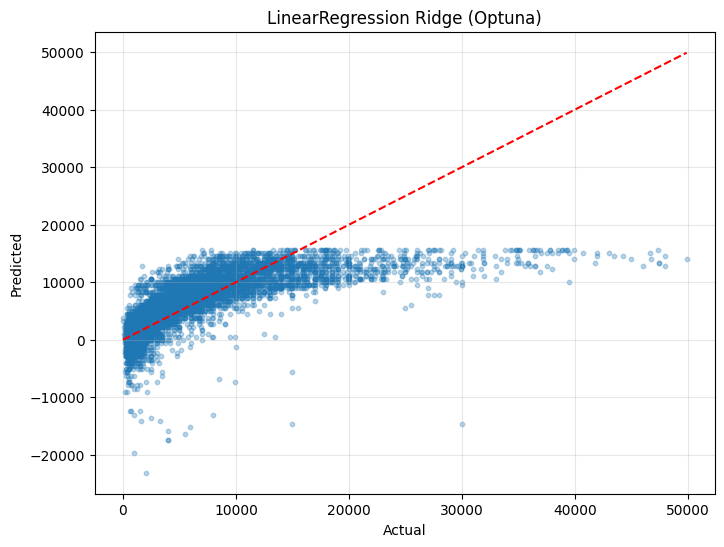

Модель: Lasso
[GridSearch] Лучшие параметры: {'alpha': 1} | R2: 0.4951
[RandomSearch] Лучшие параметры: {'alpha': 5.908361216819946} | R2: 0.4951
[Optuna] Лучшие параметры: {'alpha': 2.150967947734484} | R2: 0.4951


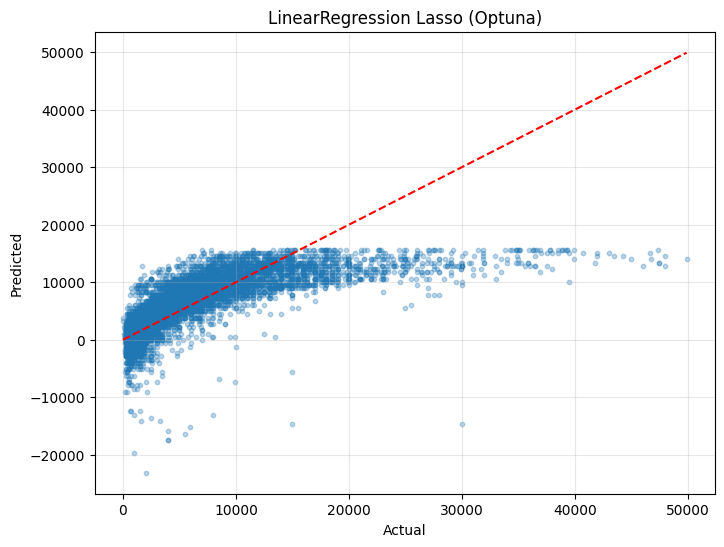

Модель: ElasticNet
[GridSearch] Лучшие параметры: {'alpha': 0.1, 'l1_ratio': 0.8} | R2: 0.4949
[RandomSearch] Лучшие параметры: {'alpha': 0.30584494295802445, 'l1_ratio': 0.9699098521619943} | R2: 0.4951
[Optuna] Лучшие параметры: {'alpha': 0.1747184612313024, 'l1_ratio': 0.9541218213108222} | R2: 0.4951


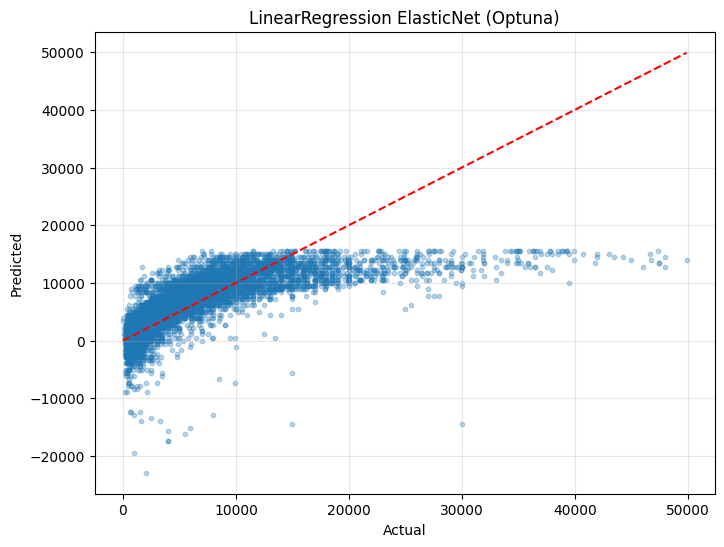

In [ ]:
# 1. Находим лучший признак 
corr_with_target = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True)['price_usd'].drop('price_usd')
best_feature = corr_with_target.abs().idxmax()

X_train_s = X_train[[best_feature]]
X_test_s = X_test[[best_feature]]

print(f"Лучший признак: {best_feature}")
print(f"Корреляция с price_usd: {corr_with_target[best_feature]:.4f}\n")


# 2. Масштабирем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test_s)

# 3. Цикл обучения и вывода графиков
for name, config in models_config.items():
    print(f"Модель: {name}")
    
    # GridSearchCV
    grid = GridSearchCV(config['model'], config['grid_params'], cv=5)
    grid.fit(X_train_scaled, y_train)
    print(f"[GridSearch] Лучшие параметры: {grid.best_params_} | R2: {grid.best_score_:.4f}")

    # RandomizedSearchCV
    rand = RandomizedSearchCV(config['model'], config['dist_params'], n_iter=10, cv=5, random_state=42)
    rand.fit(X_train_scaled, y_train)
    print(f"[RandomSearch] Лучшие параметры: {rand.best_params_} | R2: {rand.best_score_:.4f}")

    # Optuna
    def objective(trial):
        # Подбираем alpha для всех, и l1_ratio дополнительно для ElasticNet
        a = trial.suggest_float('alpha', *config['optuna_range'])
        if name == 'ElasticNet':
            l1 = trial.suggest_float('l1_ratio', 0, 1)
            m = ElasticNet(alpha=a, l1_ratio=l1)
        elif name == 'Ridge':
            m = Ridge(alpha=a)
        else:
            m = Lasso(alpha=a)
            
        return cross_val_score(m, X_train_scaled, y_train, cv=5).mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=15, show_progress_bar=False)
    print(f"[Optuna] Лучшие параметры: {study.best_params} | R2: {study.best_value:.4f}")

    if name == 'ElasticNet':
        final_model = ElasticNet(**study.best_params)
    elif name == 'Ridge':
        final_model = Ridge(**study.best_params)
    else:
        final_model = Lasso(**study.best_params)
        
    final_model.fit(X_train_scaled, y_train)
    models_list['Simple'] = final_model
    y_pred = final_model.predict(X_test_scaled)
    
    plot_regression_results(y_test, y_pred, f"LinearRegression {name} (Optuna)")

# 3.2. Множественная линейная регрессия

Модель: Ridge
[GridSearch] Лучшие параметры: {'alpha': 100} | R2: 0.7265
[RandomSearch] Лучшие параметры: {'alpha': 73.2993941811405} | R2: 0.7265
[Optuna] Лучшие параметры: {'alpha': 72.259324607706} | R2: 0.7265


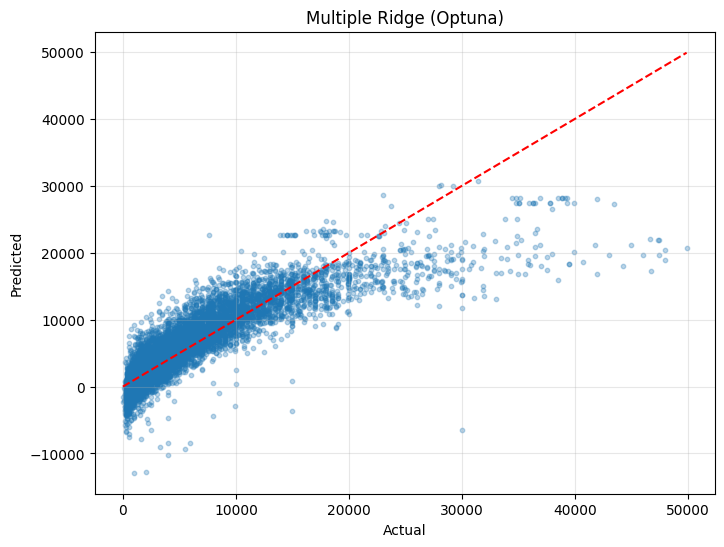

Модель: Lasso
[GridSearch] Лучшие параметры: {'alpha': 10} | R2: 0.7265
[RandomSearch] Лучшие параметры: {'alpha': 5.908361216819946} | R2: 0.7265
[Optuna] Лучшие параметры: {'alpha': 7.312961207440367} | R2: 0.7265


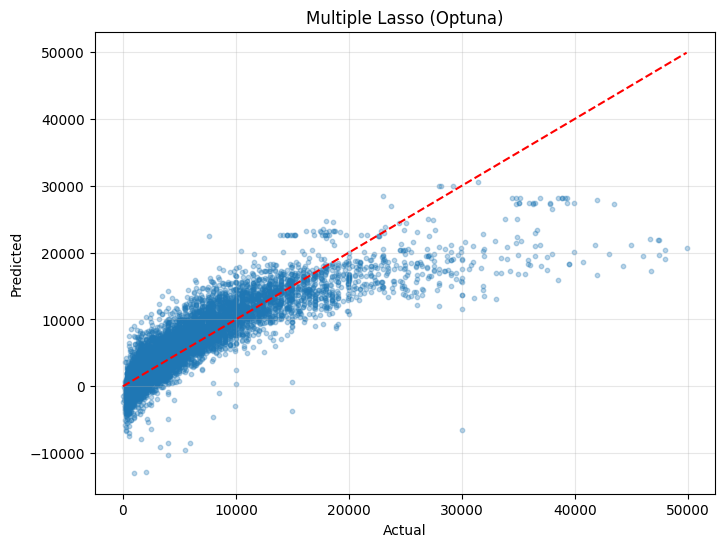

Модель: ElasticNet
[GridSearch] Лучшие параметры: {'alpha': 0.1, 'l1_ratio': 0.8} | R2: 0.7263
[RandomSearch] Лучшие параметры: {'alpha': 0.30584494295802445, 'l1_ratio': 0.9699098521619943} | R2: 0.7264
[Optuna] Лучшие параметры: {'alpha': 4.88126001571001, 'l1_ratio': 0.9945057309660824} | R2: 0.7263


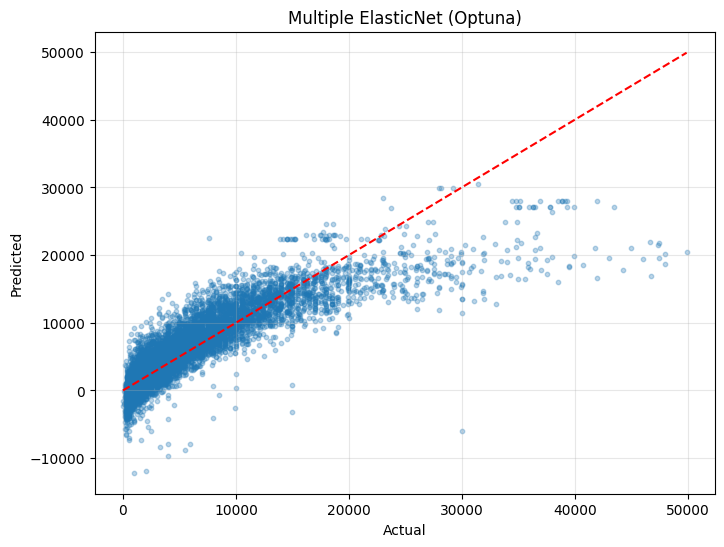

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Используем весь X_train
X_test_scaled = scaler.transform(X_test)

for name, config in models_config.items():
    print(f"Модель: {name}")
    
    # GridSearchCV
    grid = GridSearchCV(config['model'], config['grid_params'], cv=5)
    grid.fit(X_train_scaled, y_train)
    print(f"[GridSearch] Лучшие параметры: {grid.best_params_} | R2: {grid.best_score_:.4f}")

    # RandomizedSearchCV
    rand = RandomizedSearchCV(config['model'], config['dist_params'], n_iter=10, cv=5, random_state=42)
    rand.fit(X_train_scaled, y_train)
    print(f"[RandomSearch] Лучшие параметры: {rand.best_params_} | R2: {rand.best_score_:.4f}")

    # Optuna
    def objective(trial):
        a = trial.suggest_float('alpha', *config['optuna_range'])
        if name == 'ElasticNet':
            l1 = trial.suggest_float('l1_ratio', 0, 1)
            m = ElasticNet(alpha=a, l1_ratio=l1)
        elif name == 'Ridge':
            m = Ridge(alpha=a) 
        else:
            m = Lasso(alpha=a, max_iter=10000)
        return cross_val_score(m, X_train_scaled, y_train, cv=5).mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15)
    print(f"[Optuna] Лучшие параметры: {study.best_params} | R2: {study.best_value:.4f}")

    params = study.best_params
    if name == 'ElasticNet':
        final_model = ElasticNet(**study.best_params)
    elif name == 'Ridge':
        final_model = Ridge(**study.best_params)
    else:
        final_model = Lasso(**study.best_params)

    final_model.fit(X_train_scaled, y_train)
    models_list['Multiple'] = final_model
    y_pred = final_model.predict(X_test_scaled)
    
    plot_regression_results(y_test, y_pred, f"Multiple {name} (Optuna)")

# 3.3. Полиномиальная регрессия 

Лучшая степень: 1
R2: 0.7308


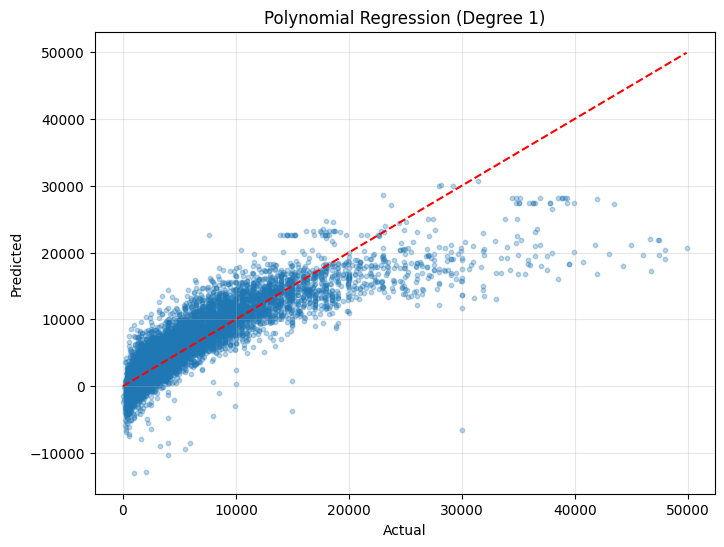

In [41]:
# 1. Функция для создания пайплайна
def create_pipeline(model, degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# 2. Функция для Optuna
def obj_poly(trial):
    # Выбираем степень: 1 (прямая) или 2 (кривая)
    degree = trial.suggest_int("degree", 1, 2)
    
    # Считаем качество на кросс-валидации
    score = cross_val_score(
        create_pipeline(LinearRegression(), degree),
        X_train, y_train, cv=3, scoring='r2', n_jobs=-1
    ).mean()
    return score

# 3. Поиск
study_poly = optuna.create_study(direction="maximize")
study_poly.optimize(obj_poly, n_trials=8)

# 4. Обучение с лучшей степенью
bp = study_poly.best_params
model_poly = create_pipeline(LinearRegression(), bp["degree"])
model_poly.fit(X_train, y_train)

# 5. Вывод
y_pred = model_poly.predict(X_test)
print(f"Лучшая степень: {bp['degree']}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

plot_regression_results(y_test, y_pred, f"Polynomial Regression (Degree {bp['degree']})")

# 3.4 Байесовская регрессия

Лучшие параметры: {'alpha_1': 8.878254723761429e-07, 'lambda_1': 7.524993581882832e-06}
R2: 0.7308


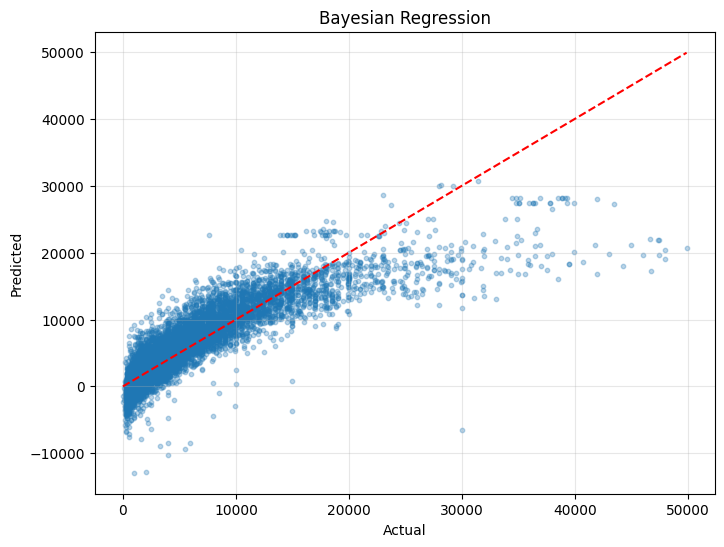

In [42]:
# 1. Пайплайн
def create_bayesian_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', BayesianRidge())
    ])

# 2. Функция для Optuna
def obj_bayesian(trial):
    # Параметры
    alpha_1 = trial.suggest_float("alpha_1", 1e-7, 1e-5, log=True)
    lambda_1 = trial.suggest_float("lambda_1", 1e-7, 1e-5, log=True)
    
    model = BayesianRidge(alpha_1=alpha_1, lambda_1=lambda_1)
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    return cross_val_score(pipe, X_train, y_train, cv=3, scoring='r2', n_jobs=-1).mean()

# 3. Поиск
study_bayesian = optuna.create_study(direction="maximize")
study_bayesian.optimize(obj_bayesian, n_trials=10)

# 4. Финальная модель
bp = study_bayesian.best_params
model_bayesian = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BayesianRidge(**bp))
])
model_bayesian.fit(X_train, y_train)

# 5. Вывод
y_pred = model_bayesian.predict(X_test)
print(f"Лучшие параметры: {bp}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

plot_regression_results(y_test, y_pred, "Bayesian Regression")

# 3.5 Робастная регрессия

Лучшие параметры: {'epsilon': 1.999405377157109, 'alpha': 0.00044614273921838937}
Huber R2: 0.7207


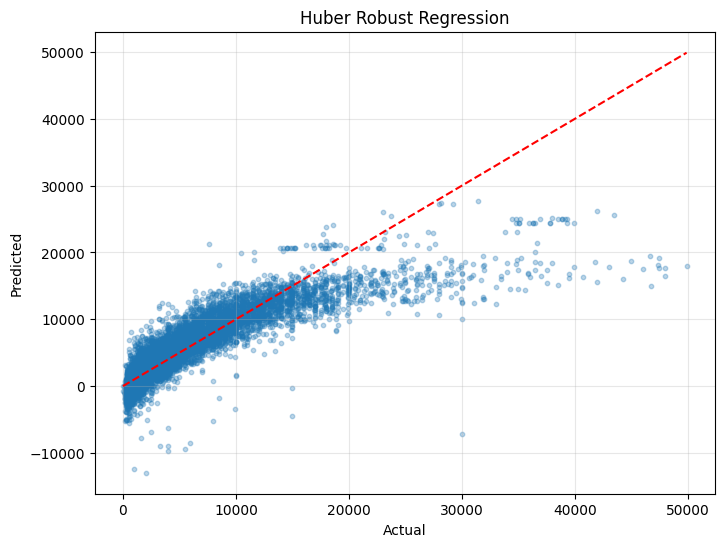

In [43]:
# 1. Пайплайн
def create_huber_pipeline(epsilon, alpha):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=2000))
    ])

# 2. Функция для Optuna
def obj_huber(trial):
    # epsilon отвечает за то, какие точки считать выбросами (чем меньше, тем строже)
    epsilon = trial.suggest_float("epsilon", 1.1, 2.0)
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    
    score = cross_val_score(
        create_huber_pipeline(epsilon, alpha),
        X_train, y_train, cv=3, scoring='r2', n_jobs=-1
    ).mean()
    return score

# 3. Поиск
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_huber = optuna.create_study(direction="maximize")
study_huber.optimize(obj_huber, n_trials=15)

# 4. Финальная модель
bp = study_huber.best_params
model_huber = create_huber_pipeline(**bp)
model_huber.fit(X_train, y_train)

# 5. Вывод
y_pred = model_huber.predict(X_test)
print(f"Лучшие параметры: {bp}")
print(f"Huber R2: {r2_score(y_test, y_pred):.4f}")

plot_regression_results(y_test, y_pred, "Huber Robust Regression")

# 4. Оценка качества моделей

Уже готовые метрики

In [56]:
def calculate_metrics_final(models, X_test_raw, X_test_scaled, y_test):
    results = []
    best_feature_idx = list(X_train.columns).index(best_feature)

    for name, model in models.items():
        if name == 'Simple':
            current_X = X_test_scaled[:, [best_feature_idx]]
        elif name in ['Polynomial', 'Bayesian', 'Robust']:
            current_X = X_test_raw
        else:
            current_X = X_test_scaled

        y_pred = model.predict(current_X)
        
        # Считаем MSE отдельно
        mse = mean_squared_error(y_test, y_pred)
        
        results.append({
            "Model": name,
            "R²": round(r2_score(y_test, y_pred), 4),
            "MAE": round(mean_absolute_error(y_test, y_pred), 2),
            "MSE": f"{mse:.2e}", # <--- Добавили MSE в научном формате
            "RMSE": round(np.sqrt(mse), 2),
            "MAPE": f"{mean_absolute_percentage_error(y_test, y_pred):.2%}"
        })
    return pd.DataFrame(results)

# Запуск
df_results = calculate_metrics_final(models_list, X_test, X_test_scaled, y_test)
print(df_results.to_string(index=False))


     Model     R²     MAE      MSE    RMSE    MAPE
    Simple 0.5039 2910.42 2.01e+07 4478.89 189.11%
  Multiple 0.7308 2116.79 1.09e+07 3299.47 121.87%
Polynomial 0.7308 2128.90 1.09e+07 3299.38 123.38%
  Bayesian 0.7308 2128.38 1.09e+07 3299.29 123.34%
    Robust 0.7207 1987.54 1.13e+07 3360.95  72.40%


In [ ]:
def get_all_metrics(model, X, y, use_custom=False):
    y_pred = model.predict(X)
    if use_custom:
        return [ml.custom_r2(y, y_pred), ml.custom_mse(y, y_pred), 
                ml.custom_rmse(y, y_pred), ml.custom_mae(y, y_pred), ml.custom_mape(y, y_pred)]
    else:
        return [sk_m.r2_score(y, y_pred), sk_m.mean_squared_error(y, y_pred), 
                np.sqrt(sk_m.mean_squared_error(y, y_pred)), sk_m.mean_absolute_error(y, y_pred), 
                sk_m.mean_absolute_percentage_error(y, y_pred)]
    
# Находим порядковый номер лучшего признака
best_feature_idx = list(X_train.columns).index(best_feature)

columns = pd.MultiIndex.from_product([['Train Data', 'Test Data'], ['R²', 'MSE', 'RMSE', 'MAE', 'MAPE']])
table1 = pd.DataFrame(index=models_list.keys(), columns=columns)

for name, model in models_list.items():
    curr_X_train = X_train_scaled if name != 'Simple' else X_train_scaled[:, [best_feature_idx]]
    curr_X_test = X_test_scaled if name != 'Simple' else X_test_scaled[:, [best_feature_idx]]
    
    if name in ['Polynomial', 'Bayesian', 'Robust']:
        curr_X_train, curr_X_test = X_train, X_test
        if name == 'Simple': curr_X_test = X_test[[best_feature]] # на всякий случай

    table1.loc[name, 'Train Data'] = get_all_metrics(model, curr_X_train, y_train, use_custom=True)
    table1.loc[name, 'Test Data'] = get_all_metrics(model, curr_X_test, y_test, use_custom=True)

print("Сравнение Train и Test")
display(table1.astype(float).round(4))



Образец 1: Сравнение Train и Test


Train Data                                             Test Data  \
                   R²           MSE       RMSE        MAE    MAPE        R²   
Simple         0.4953  2.093029e+07  4574.9637  2942.2662  1.1753    0.5039   
Multiple       0.7275  1.130272e+07  3361.9523  2128.0341  1.2154    0.7308   
Polynomial     0.7278  1.128982e+07  3360.0332  2139.0483  1.2348    0.7308   
Bayesian       0.7278  1.128985e+07  3360.0372  2138.5872  1.2341    0.7308   
Robust         0.7120  1.194460e+07  3456.0962  2009.6158  1.0322    0.7207   

                                                        
                     MSE       RMSE        MAE    MAPE  
Simple      2.006041e+07  4478.8851  2910.4218  1.8911  
Multiple    1.088650e+07  3299.4695  2116.7871  1.2187  
Polynomial  1.088588e+07  3299.3750  2128.9040  1.2338  
Bayesian    1.088531e+07  3299.2886  2128.3797  1.2334  
Robust      1.129598e+07  3360.9485  1987.5355  0.7240

In [ ]:
def fill_table(table, use_both_methods=False):
    for name, model in models_list.items():
        if name == 'Simple':
            curr_X = X_test_scaled[:, [best_feature_idx]]
        elif name in ['Polynomial', 'Bayesian', 'Robust']:
            curr_X = X_test
        else:
            curr_X = X_test_scaled

        if use_both_methods:
            table.loc[name, 'Scikit-learn'] = get_all_metrics(model, curr_X, y_test, use_custom=False)
            table.loc[name, 'Кастомные функции'] = get_all_metrics(model, curr_X, y_test, use_custom=True)

columns2 = pd.MultiIndex.from_product([['Scikit-learn', 'Кастомные функции'], ['R²', 'MSE', 'RMSE', 'MAE', 'MAPE']])
table2 = pd.DataFrame(index=models_list.keys(), columns=columns2)

fill_table(table2, use_both_methods=True)
display(table2.astype(float).round(4))


Scikit-learn                                              \
                     R²           MSE       RMSE        MAE    MAPE   
Simple           0.5039  2.006041e+07  4478.8851  2910.4218  1.8911   
Multiple         0.7308  1.088650e+07  3299.4695  2116.7871  1.2187   
Polynomial       0.7308  1.088588e+07  3299.3750  2128.9040  1.2338   
Bayesian         0.7308  1.088531e+07  3299.2886  2128.3797  1.2334   
Robust           0.7207  1.129598e+07  3360.9485  1987.5355  0.7240   

           Кастомные функции                                              
                          R²           MSE       RMSE        MAE    MAPE  
Simple                0.5039  2.006041e+07  4478.8851  2910.4218  1.8911  
Multiple              0.7308  1.088650e+07  3299.4695  2116.7871  1.2187  
Polynomial            0.7308  1.088588e+07  3299.3750  2128.9040  1.2338  
Bayesian              0.7308  1.088531e+07  3299.2886  2128.3797  1.2334  
Robust                0.7207  1.129598e+07  3360.9485  1987.5355  0.7240

# Вывод


В ходе выполнения были реализованы алгоритмы линейной регрессии для прогнозирования стоимости автомобилей на основе набора данных из 47 признаков. Были применены методы регуляризации (Lasso, Ridge, ElasticNet), а также подбор гиперпараметров с помощью инструментов `GridSearchCV`, `RandomizedSearchCV` и `Optuna`.

### 1. Сравнение моделей и выбор лучшей
Согласно итоговой таблице метрик, все множественные модели показали стабильно высокий коэффициент детерминации $R^2 \approx 0.73$, что на 23% выше показателей простой линейной регрессии ($R^2 \approx 0.50$). 

**Лучшей моделью по совокупности показателей признана Робастная регрессия (Huber Regressor).**

**Обоснование:**
*   **Устойчивость к выбросам:** Несмотря на то, что $R^2$ у Huber-регрессии ($0.7207$) незначительно ниже, чем у Ridge ($0.7308$), она показала **наименьшую среднюю абсолютную ошибку (MAE = 1987.54)**. Это говорит о том, что модель лучше игнорирует аномальные значения (слишком дешевые или дорогие авто) и точнее предсказывает цену основной массы объявлений.
*   **Точность предсказания (MAPE):** Данная модель показала самый низкий уровень относительной ошибки (**72.40%**), в то время как у остальных моделей этот показатель превышает 120%.

### 2. Уравнение регрессии
Выбранная модель представляет собой множественную линейную регрессию. Уравнение восстановленной модели имеет вид:

$$y = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \dots + w_{47} \cdot x_{47}$$

Где:
*   $y$ — предсказанная стоимость автомобиля;
*   $w_0$ — свободный коэффициент (интерцепт), полученный через `model.intercept_`;
*   $w_i$ — веса признаков (коэффициенты важности), полученные через `model.coef_`;
*   $x_i$ — стандартизированные значения признаков (год выпуска, пробег, мощность и др.).

### 3. Итоговое заключение
1.  **Кастомные метрики:** Самостоятельная реализация функций в модуле `metrics_lib.py` полностью подтвердила свою корректность, выдав результаты, идентичные библиотеке `scikit-learn`.
2.  **Нелинейность данных:** Визуальный анализ остатков (графики Actual vs Predicted) выявил «изгиб» в ошибках, что указывает на нелинейный характер зависимости цен. В дальнейшем точность можно повысить за счет логарифмирования целевой переменной или использования ансамблевых методов (Random Forest, Gradient Boosting).
3.  **Гиперпараметры:** Оптимизация через `Optuna` оказалась наиболее эффективной, позволив найти точные значения параметров регуляризации за меньшее количество итераций по сравнению с полным перебором.
